In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generer_donnees(beta0_vrai, beta1_vrai, n, sigma_eps, seed=None):
    np.random.seed(None)
    x = np.random.uniform(0.01, 0.15, n)
    epsilon = np.random.normal(0, sigma_eps, n)
    y = beta0_vrai + beta1_vrai * x + epsilon
    return x, y

def estimer(x, y):
  x_moy = np.mean(x)
  y_moy = np.mean(y)
  cov = np.mean((x - x_moy) * (y - y_moy))
  var = np.mean((x - x_moy)**2)
  beta1_estimer = cov / var
  beta0_estimer = y_moy - beta1_estimer * x_moy
  return beta0_estimer, beta1_estimer

In [3]:
# Boucle Monte Carlo
k = 10000
beta0_liste = []
beta1_liste = []

for i in range(k):
  x, y = generer_donnees(beta0_vrai=0.0, beta1_vrai=0.35, n=6, sigma_eps=0.002)
  beta0, beta1 = estimer(x, y)
  beta0_liste.append(beta0)
  beta1_liste.append(beta1)

beta0_liste = np.array(beta0_liste)
beta1_liste = np.array(beta1_liste)

print("Nombre de beta1 collectés :", len(beta1_liste))
print("Moyenne des beta1 estimés :", np.mean(beta1_liste))
print("Ecart-type des beta1     :", np.std(beta1_liste))

Nombre de beta1 collectés : 10000
Moyenne des beta1 estimés : 0.34999046456218186
Ecart-type des beta1     : 0.025664252945508153


In [4]:
x, y = generer_donnees(beta0_vrai=0.0, beta1_vrai=0.35, n=6, sigma_eps=0.002, seed=42)
print("x =", x)
print("y =", y)
print("verification, 0.35 * x =", 0.35 * x)

x = [0.12637863 0.03771556 0.01489424 0.1473024  0.05440782 0.0228811 ]
y = [0.0490352  0.01209702 0.00612523 0.05329173 0.02318324 0.00817504]
verification, 0.35 * x = [0.04423252 0.01320045 0.00521298 0.05155584 0.01904274 0.00800839]


In [5]:
x, y = generer_donnees(beta0_vrai=0.0, beta1_vrai=0.35, n=6, sigma_eps=0.002, seed=42)
beta0_estimer, beta1_estimer = estimer(x, y)
print("beta0 estimé :", beta0_estimer)
print("beta1 estimé :", beta1_estimer)

beta0 estimé : 0.0009362581820118801
beta1 estimé : 0.3537273166880631


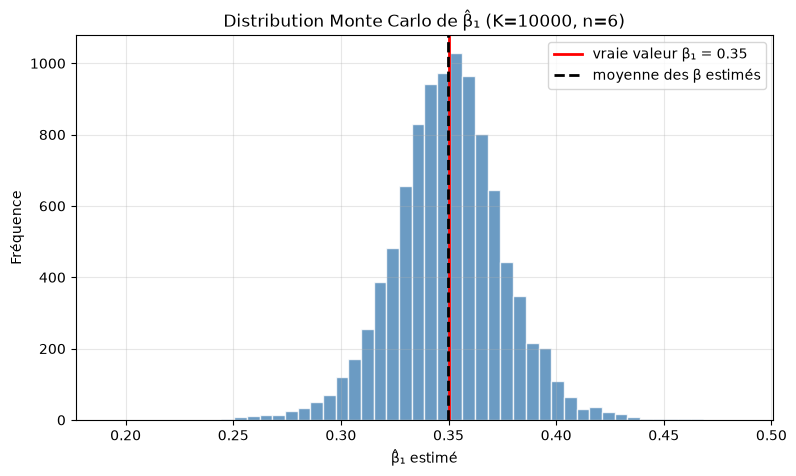

In [6]:
plt.figure(figsize=(9, 5))
plt.hist(beta1_liste, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(0.35, color="red", linewidth=2, label="vraie valeur β₁ = 0.35")
plt.axvline(np.mean(beta1_liste), color="black", linestyle="--", linewidth=2, label="moyenne des β estimés")
plt.xlabel("β̂₁ estimé")
plt.ylabel("Fréquence")
plt.title("Distribution Monte Carlo de β̂₁ (K=10000, n=6)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

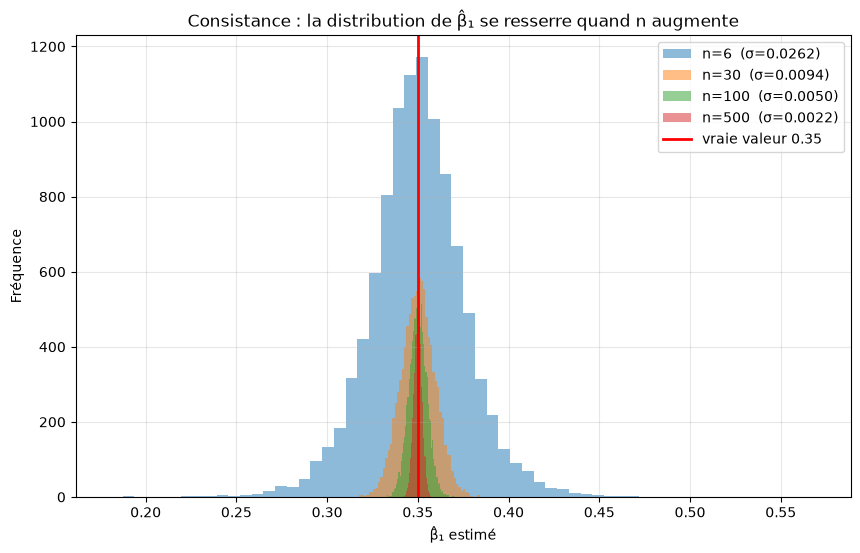

In [7]:
tailles = [6, 30, 100, 500]
K = 10000

plt.figure(figsize=(10, 6))

for n in tailles:
    beta1_liste = []
    for i in range(K):
        x, y = generer_donnees(beta0_vrai=0.0, beta1_vrai=0.35, n=n, sigma_eps=0.002)
        b0, b1 = estimer(x, y)
        beta1_liste.append(b1)
    beta1_liste = np.array(beta1_liste)
    ecart = np.std(beta1_liste)
    plt.hist(beta1_liste, bins=60, alpha=0.5, label=f"n={n}  (σ={ecart:.4f})")

plt.axvline(0.35, color="red", linewidth=2, label="vraie valeur 0.35")
plt.xlabel("β̂₁ estimé")
plt.ylabel("Fréquence")
plt.title("Consistance : la distribution de β̂₁ se resserre quand n augmente")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()